# (DMPK) Oncology Translational Workflow, POC

This notebook simulates a **benchmarked oncology DMPK dataset** and applies an end-to-end analysis pipeline. The workflow includes:

1. Creation of a synthetic discovery portfolio with **literature-benchmarked assay ranges**.
2. Exploratory analysis of **ADME, PK, exposure, safety, and translational metrics**.
3. **Machine learning and AI-style modelling** for developability classification and human PK projection.
4. Simple **PBPK-inspired and PK/PD-oriented summaries** for candidate progression.
5. Multi-objective **candidate ranking** for an oncology portfolio.

## Important note
This is a **simulation**, not a real project dataset. Values are generated to stay within ranges broadly consistent with peer-reviewed DMPK literature, especially around:
- microsomal and hepatocyte intrinsic clearance,
- plasma protein binding,
- Caco-2 permeability and efflux,
- allometric scaling and first-in-human reasoning,
- translational PK/PD in oncology,
- CYP-mediated DDI concepts.

The purpose is to show how such a translational DMPK workflow could be structured for analysis.

## Benchmarking literature used to anchor simulated ranges
- Zhou, Q., & Gallo, J. M. (2011). *The pharmacokinetic/pharmacodynamic pipeline: translating anticancer drug pharmacology to the clinic*. AAPS Journal, 13(1), 111–120. https://pubmed.ncbi.nlm.nih.gov/21246315/
- Chao, P., Uss, A. S., & Houston, J. B. (2010). *Use of intrinsic clearance for prediction of human hepatic clearance*. Expert Opinion on Drug Metabolism & Toxicology, 6(2), 189–198. https://pubmed.ncbi.nlm.nih.gov/20073997/
- Chiba, M., Naritomi, Y., & Sugiyama, Y. (2009). *Prediction of hepatic clearance in human from in vitro data for successful drug development*. AAPS Journal, 11(2), 262–276. https://pubmed.ncbi.nlm.nih.gov/19408130/
- Gajula, S. N. R., et al. (2021). *Drug metabolic stability in early drug discovery to develop potential lead compounds*. Drug Metabolism Reviews, 53(4), 459–477. https://pubmed.ncbi.nlm.nih.gov/34406889/
- Yim, D. S. (2020). *Predicting human pharmacokinetics from preclinical data*. Korean Journal of Physiology & Pharmacology, 24(6), 501–510. https://pubmed.ncbi.nlm.nih.gov/33062626/
- Di, L. (2021). *An update on the importance of plasma protein binding in drug discovery and development*. Expert Opinion on Drug Discovery, 16(12), 1453–1465. https://pubmed.ncbi.nlm.nih.gov/34403271/
- Smith, D. A., Di, L., & Kerns, E. H. (2010). *The effect of plasma protein binding on in vivo efficacy: misconceptions in drug discovery*. Nature Reviews Drug Discovery, 9(12), 929–939. https://pubmed.ncbi.nlm.nih.gov/21119731/
- Cheng, K. C., et al. (2008). *Prediction of oral drug absorption in humans, from cultured Caco-2 cells and non-clinical animal studies*. Expert Opinion on Drug Metabolism & Toxicology, 4(5), 581–590. https://pubmed.ncbi.nlm.nih.gov/18484916/
- van Breemen, R. B., & Li, Y. (2005). *Caco-2 cell permeability assays to measure drug absorption*. Expert Opinion on Drug Metabolism & Toxicology, 1(2), 175–185. https://pubmed.ncbi.nlm.nih.gov/16922635/
- Mahmood, I. (2007). *Application of allometric principles for the prediction of pharmacokinetics in human and veterinary drug development*. Advanced Drug Delivery Reviews, 59(11), 1177–1192. https://pubmed.ncbi.nlm.nih.gov/17826864/
- Sharma, V., & McNeill, J. H. (2009). *To scale or not to scale: the principles of dose extrapolation*. British Journal of Pharmacology, 157(6), 907–921. https://pubmed.ncbi.nlm.nih.gov/19508398/



In [2]:

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    mean_absolute_error, r2_score, confusion_matrix, precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

np.random.seed(42)

OUTDIR = Path("dmpk_notebook_outputs")
FIGDIR = OUTDIR / "figures"
TBLDIR = OUTDIR / "tables"
OUTDIR.mkdir(exist_ok=True)
FIGDIR.mkdir(exist_ok=True)
TBLDIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)



## 1. Simulate a literature-benchmarked oncology DMPK portfolio

The synthetic compounds below are constrained to ranges commonly encountered in discovery DMPK literature. The idea is not to generate an internally coherent screening set whose values sit inside plausible ranges discussed across published reviews.

### Approximate literature-inspired anchors used here
- **HLM intrinsic clearance** spans low, moderate, and high-turnover compounds, commonly expressed over broad ranges in µL/min/mg protein.
- **Plasma fraction unbound (f_u)** commonly spans from very low values for lipophilic/basic compounds to substantially higher values for less protein-bound molecules.
- **Caco-2 apparent permeability (Papp)** typically distinguishes low-permeability from highly permeable compounds across roughly log-scale ranges.
- **Efflux ratio**, **CYP inhibition IC50**, and **hERG IC50** are included as medicinal chemistry triage-style endpoints.
- **Mouse, rat, and dog clearance plus Vss** are simulated to support allometric reasoning and translational dose projection.

The simulation deliberately links structure-like descriptors to DMPK outcomes, for example:
- increasing **logP** tends to reduce solubility and free fraction,
- high **tPSA** and high **HBD/HBA burden** reduce permeability,
- high **intrinsic clearance** increases systemic clearance,
- high **efflux** tends to reduce oral exposure,
- improved tumor partition and potency strengthen translational attractiveness.


In [5]:

n = 320

compound_id = [f"CRH_{i:03d}" for i in range(1, n+1)]

mw = np.clip(np.random.normal(430, 85, n), 220, 780)
clogp = np.clip(np.random.normal(2.8, 1.4, n), -0.5, 7.0)
tpsa = np.clip(np.random.normal(95, 35, n), 20, 220)
hbd = np.clip(np.random.poisson(1.6, n), 0, 6)
hba = np.clip(np.random.poisson(6.0, n), 1, 14)
rotb = np.clip(np.random.poisson(7.0, n), 1, 18)
pka = np.clip(np.random.normal(7.0, 1.8, n), 2.0, 12.0)
aromatic_rings = np.clip(np.random.poisson(2.2, n)+1, 1, 6)
modality = np.where(mw < 550, "small_molecule", "large_like")
target_class = np.random.choice(
    ["kinase", "DNA_damage_response", "epigenetic", "metabolic", "protein_degrader_proxy"],
    size=n,
    p=[0.30, 0.22, 0.16, 0.20, 0.12]
)

# Solubility, lower with higher MW and clogP, slightly improved by ionization
logS = (
    -2.0
    - 0.38 * (clogp - 2.5)
    - 0.0024 * (mw - 400)
    + 0.015 * (8 - np.abs(pka - 7))
    - 0.004 * (tpsa - 90)
    + np.random.normal(0, 0.35, n)
)
solubility_uM = np.clip(10 ** logS * 1e3, 0.05, 5000)

# Plasma free fraction, inverse relation to logP and aromaticity
log_fu = (
    -1.0
    - 0.28 * clogp
    - 0.08 * aromatic_rings
    + 0.003 * (tpsa - 90)
    + np.random.normal(0, 0.25, n)
)
fu_plasma = np.clip(10 ** log_fu, 0.001, 0.9)

# Microsomal and hepatocyte intrinsic clearance, literature-scale style ranges
log_hlm_clint = (
    1.2
    + 0.22 * clogp
    - 0.006 * (tpsa - 90)
    - 0.25 * np.log10(solubility_uM + 1)
    + 0.18 * (pka > 8).astype(float)
    + np.random.normal(0, 0.35, n)
)
hlm_clint = np.clip(10 ** log_hlm_clint, 1, 250)

hep_clint = np.clip(
    hlm_clint * np.exp(np.random.normal(np.log(1.5), 0.35, n)),
    2, 450
)

# Caco-2 permeability and efflux
log_papp = (
    0.65
    + 0.20 * clogp
    - 0.0065 * tpsa
    - 0.06 * hbd
    - 0.03 * rotb
    + np.random.normal(0, 0.22, n)
)
caco2_papp = np.clip(10 ** log_papp, 0.05, 80)

efflux_ratio = np.clip(
    1.0
    + 0.010 * (tpsa - 80)
    + 0.25 * (clogp > 4.5).astype(float)
    + 0.35 * (pka > 8.5).astype(float)
    + np.random.normal(0, 0.45, n),
    0.7, 12
)

# CYP inhibition and hERG, lower IC50 indicates stronger liability
cyp3a4_ic50_uM = np.clip(
    10 ** (
        1.2
        - 0.18 * clogp
        - 0.05 * aromatic_rings
        + 0.003 * tpsa
        + np.random.normal(0, 0.28, n)
    ),
    0.03, 100
)
cyp2d6_ic50_uM = np.clip(
    10 ** (
        1.1
        - 0.12 * clogp
        - 0.08 * (pka > 8).astype(float)
        + 0.002 * tpsa
        + np.random.normal(0, 0.30, n)
    ),
    0.03, 100
)
herg_ic50_uM = np.clip(
    10 ** (
        1.0
        - 0.25 * clogp
        - 0.06 * aromatic_rings
        + 0.002 * tpsa
        + np.random.normal(0, 0.32, n)
    ),
    0.03, 100
)

# Protein target potency and cellular potency
biochemical_ic50_nM = np.clip(
    10 ** (
        2.0
        - 0.12 * clogp
        - 0.03 * aromatic_rings
        + 0.001 * tpsa
        + np.random.normal(0, 0.35, n)
    ),
    0.5, 5000
)
cellular_ec50_nM = np.clip(
    biochemical_ic50_nM * np.exp(
        0.35
        + 0.004 * tpsa
        + 0.25 * np.maximum(efflux_ratio - 1, 0)
        - 0.15 * np.log10(solubility_uM + 1)
        + np.random.normal(0, 0.30, n)
    ),
    2, 20000
)

# Species clearance (mL/min/kg), derived from intrinsic clearance and fu
mouse_cl = np.clip(
    4.0 + 0.23 * hlm_clint + 10 * fu_plasma + np.random.normal(0, 3.0, n),
    1, 90
)
rat_cl = np.clip(
    3.0 + 0.18 * hep_clint + 8 * fu_plasma + np.random.normal(0, 3.5, n),
    1, 80
)
dog_cl = np.clip(
    2.0 + 0.10 * hep_clint + 6 * fu_plasma + np.random.normal(0, 2.8, n),
    0.5, 55
)

mouse_vss = np.clip(
    0.4 + 0.30 * clogp + 0.8 * (1 - fu_plasma) + np.random.normal(0, 0.35, n),
    0.15, 8.0
)
rat_vss = np.clip(mouse_vss * np.exp(np.random.normal(np.log(1.05), 0.18, n)), 0.15, 9.0)
dog_vss = np.clip(mouse_vss * np.exp(np.random.normal(np.log(0.95), 0.20, n)), 0.10, 9.0)

# Elimination half-life approximation
mouse_t12_h = np.clip(0.693 * mouse_vss / (mouse_cl / 60.0), 0.15, 24)
rat_t12_h = np.clip(0.693 * rat_vss / (rat_cl / 60.0), 0.2, 30)
dog_t12_h = np.clip(0.693 * dog_vss / (dog_cl / 60.0), 0.3, 48)

# Oral bioavailability proxy
oral_F = np.clip(
    95
    - 0.22 * hlm_clint
    + 0.55 * np.log10(solubility_uM + 1) * 10
    + 0.55 * caco2_papp
    - 2.5 * np.maximum(efflux_ratio - 1, 0)
    - 6 * (cyp3a4_ic50_uM < 1).astype(float)
    + np.random.normal(0, 9.0, n),
    1, 95
)

# Tumor distribution and target coverage proxy
tumor_plasma_ratio = np.clip(
    0.4
    + 0.18 * clogp
    - 0.003 * tpsa
    + 0.25 * (target_class == "kinase").astype(float)
    + 0.15 * (target_class == "metabolic").astype(float)
    + np.random.normal(0, 0.20, n),
    0.1, 5.0
)

# Simplified PK/PD coverage score
free_avg_plasma_uM = np.clip(
    (oral_F / 100) * 8 / (mouse_cl/10 + 0.6) * fu_plasma,
    0.001, 20
)
coverage_ratio = np.clip(
    (free_avg_plasma_uM * 1000 * tumor_plasma_ratio) / cellular_ec50_nM,
    0.001, 200
)

# Synthetic safety margin versus hERG and CYP
safety_margin = np.clip(
    herg_ic50_uM / (free_avg_plasma_uM + 1e-6),
    0.01, 500
)

# DDI liability score
ddi_risk_score = (
    0.45 * (cyp3a4_ic50_uM < 1.0).astype(float)
    + 0.25 * (cyp2d6_ic50_uM < 1.0).astype(float)
    + 0.20 * (efflux_ratio > 3.0).astype(float)
    + 0.10 * (oral_F > 70).astype(float)
)

# Developability labels
developability_score = (
    1.2 * np.log10(coverage_ratio + 1)
    + 0.6 * np.log10(oral_F + 1)
    + 0.5 * np.log10(safety_margin + 1)
    + 0.3 * np.log10(solubility_uM + 1)
    - 0.8 * np.log10(hlm_clint)
    - 0.6 * np.log10(efflux_ratio + 0.5)
    - 0.7 * ddi_risk_score
)
developability_tier = pd.qcut(developability_score, q=3, labels=["low", "medium", "high"])

# Human PK projection using allometric-like heuristics from 3 species
bw = {"mouse": 0.025, "rat": 0.25, "dog": 10, "human": 70}
species_w = np.array([bw["mouse"], bw["rat"], bw["dog"]])
cl_mat = np.vstack([mouse_cl, rat_cl, dog_cl]).T
v_mat = np.vstack([mouse_vss, rat_vss, dog_vss]).T

def fit_power(x, y):
    lx = np.log(x)
    ly = np.log(y)
    b, a = np.polyfit(lx, ly, 1)
    return np.exp(a), b

pred_human_cl = []
pred_human_vss = []

for i in range(n):
    a_cl, b_cl = fit_power(species_w, cl_mat[i])
    a_v, b_v = fit_power(species_w, v_mat[i])
    # Keep within common allometric neighborhoods
    b_cl = np.clip(b_cl, 0.45, 0.95)
    b_v = np.clip(b_v, 0.70, 1.10)
    pred_human_cl.append(np.clip(a_cl * (bw["human"] ** b_cl), 0.5, 35))
    pred_human_vss.append(np.clip(a_v * (bw["human"] ** b_v), 0.1, 8.0))

pred_human_cl = np.array(pred_human_cl)
pred_human_vss = np.array(pred_human_vss)
pred_human_t12_h = np.clip(0.693 * pred_human_vss / (pred_human_cl / 60.0), 1, 120)

# Human efficacious dose proxy, intentionally simple
human_eff_dose_mg = np.clip(
    (cellular_ec50_nM / 1000) / (fu_plasma * np.maximum(tumor_plasma_ratio, 0.15)) * (pred_human_cl / 5) * 50,
    2, 1200
)

# IND-like risk flag
ind_risk_flag = np.where(
    (herg_ic50_uM < 3) | (cyp3a4_ic50_uM < 0.5) | (oral_F < 15) | (coverage_ratio < 0.5),
    "elevated",
    "managed"
)

df = pd.DataFrame({
    "compound_id": compound_id,
    "modality": modality,
    "target_class": target_class,
    "mw": mw,
    "clogp": clogp,
    "tpsa": tpsa,
    "hbd": hbd,
    "hba": hba,
    "rotb": rotb,
    "pka": pka,
    "aromatic_rings": aromatic_rings,
    "solubility_uM": solubility_uM,
    "fu_plasma": fu_plasma,
    "hlm_clint_uL_min_mg": hlm_clint,
    "hepatocyte_clint_uL_min_1e6": hep_clint,
    "caco2_papp_1e6_cm_s": caco2_papp,
    "efflux_ratio": efflux_ratio,
    "cyp3a4_ic50_uM": cyp3a4_ic50_uM,
    "cyp2d6_ic50_uM": cyp2d6_ic50_uM,
    "herg_ic50_uM": herg_ic50_uM,
    "biochemical_ic50_nM": biochemical_ic50_nM,
    "cellular_ec50_nM": cellular_ec50_nM,
    "mouse_cl_mL_min_kg": mouse_cl,
    "rat_cl_mL_min_kg": rat_cl,
    "dog_cl_mL_min_kg": dog_cl,
    "mouse_vss_L_kg": mouse_vss,
    "rat_vss_L_kg": rat_vss,
    "dog_vss_L_kg": dog_vss,
    "mouse_t12_h": mouse_t12_h,
    "rat_t12_h": rat_t12_h,
    "dog_t12_h": dog_t12_h,
    "oral_F_percent": oral_F,
    "tumor_plasma_ratio": tumor_plasma_ratio,
    "free_avg_plasma_uM": free_avg_plasma_uM,
    "coverage_ratio": coverage_ratio,
    "safety_margin": safety_margin,
    "ddi_risk_score": ddi_risk_score,
    "developability_score": developability_score,
    "developability_tier": developability_tier.astype(str),
    "pred_human_cl_mL_min_kg": pred_human_cl,
    "pred_human_vss_L_kg": pred_human_vss,
    "pred_human_t12_h": pred_human_t12_h,
    "human_eff_dose_mg": human_eff_dose_mg,
    "ind_risk_flag": ind_risk_flag
})

df.head()


,compound_id,modality,target_class,mw,clogp,tpsa,hbd,hba,rotb,pka,aromatic_rings,solubility_uM,fu_plasma,hlm_clint_uL_min_mg,hepatocyte_clint_uL_min_1e6,caco2_papp_1e6_cm_s,efflux_ratio,cyp3a4_ic50_uM,cyp2d6_ic50_uM,herg_ic50_uM,biochemical_ic50_nM,cellular_ec50_nM,mouse_cl_mL_min_kg,rat_cl_mL_min_kg,dog_cl_mL_min_kg,mouse_vss_L_kg,rat_vss_L_kg,dog_vss_L_kg,mouse_t12_h,rat_t12_h,dog_t12_h,oral_F_percent,tumor_plasma_ratio,free_avg_plasma_uM,coverage_ratio,safety_margin,ddi_risk_score,developability_score,developability_tier,pred_human_cl_mL_min_kg,pred_human_vss_L_kg,pred_human_t12_h,human_eff_dose_mg,ind_risk_flag
0,CRH_001,small_molecule,protein_degrader_proxy,472.220703,2.935794,83.247536,2,3,6,8.516135,3,2.587847,0.014547,60.723911,57.169435,3.910070,0.946358,4.997405,6.241200,0.527756,70.254572,125.272135,15.558870,17.641952,7.017810,2.318418,2.820618,2.397247,6.195810,6.647863,14.203508,73.011759,0.659482,0.039413,0.207487,13.389956,0.1,0.372466,low,35.000000,8.0,9.504000,1200.000000,elevated
1,CRH_002,small_molecule,DNA_damage_response,418.247534,3.633220,153.415753,0,8,9,7.041753,6,9.390224,0.021595,14.262723,23.221995,1.134047,1.745072,4.336119,9.192463,4.316116,11.662406,52.970642,4.286551,8.326778,2.969911,2.476091,2.668896,2.101661,24.000000,13.327206,29.424139,95.000000,0.998321,0.159552,3.007026,27.051288,0.1,1.737613,high,29.692619,8.0,11.202784,729.549987,managed
2,CRH_003,small_molecule,epigenetic,485.053526,1.654491,85.914303,4,4,7,9.431828,3,51.447413,0.020481,11.974863,15.498013,0.625387,1.216154,33.507712,13.652572,8.507978,77.274369,214.803555,3.804438,7.897926,3.864848,1.680128,3.075220,1.734001,18.362689,16.190026,18.655265,95.000000,0.373261,0.158762,0.275879,53.589025,0.1,1.627454,high,32.531746,8.0,10.225089,1200.000000,elevated
3,CRH_004,large_like,DNA_damage_response,559.457538,5.729342,42.389997,0,7,4,4.277448,3,0.480831,0.001000,250.000000,450.000000,15.557822,1.237377,2.497366,1.548831,0.425479,18.472646,35.231477,55.954706,80.000000,49.980136,2.851592,3.231779,2.848395,2.119021,1.679717,2.369666,48.085858,1.148876,0.001000,0.032609,425.053771,0.0,0.334893,low,35.000000,8.0,9.504000,1200.000000,elevated
4,CRH_005,small_molecule,kinase,410.096963,1.391576,86.398993,2,9,10,4.604731,6,10.275996,0.010878,6.480989,9.357610,0.426200,1.418559,6.089536,31.174460,2.659235,38.181738,89.599625,6.879371,7.894125,0.500000,1.325935,1.018693,1.394809,8.014159,5.365667,48.000000,95.000000,0.466699,0.064188,0.334337,41.428232,0.1,1.580057,high,13.212382,8.0,25.176384,1200.000000,elevated


In [7]:

summary = df.describe(include="all").T
summary.to_csv(TBLDIR / "dataset_summary.csv")
summary.head(15)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
compound_id,320,320,CRH_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modality,320,2,small_molecule,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_class,320,5,kinase,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mw,320.0,NaN,NaN,NaN,431.265277,81.55334,220.0,374.577232,435.291685,484.175719,757.482177
clogp,320.0,NaN,NaN,NaN,2.769023,1.389938,-0.5,1.723732,2.778468,3.675247,7.0
tpsa,320.0,NaN,NaN,NaN,97.912172,33.647424,20.0,75.565588,96.848962,118.855944,187.133372
hbd,320.0,NaN,NaN,NaN,1.5625,1.227621,0.0,1.0,1.0,2.0,5.0
hba,320.0,NaN,NaN,NaN,5.85,2.374631,1.0,4.0,6.0,7.0,13.0
rotb,320.0,NaN,NaN,NaN,7.059375,2.539884,1.0,5.0,7.0,9.0,14.0
pka,320.0,NaN,NaN,NaN,6.935919,1.771717,2.0,5.844543,6.927144,8.18721,12.0



## 2. Exploratory DMPK analysis

This section looks at whether the simulated compounds behave like a plausible discovery portfolio. We examine the spread of exposure, clearance, permeability, free fraction, and translation-relevant metrics.

The main question is whether the overall portfolio contains the kinds of trade-offs DMPK frameworks manage:
- high potency but poor exposure,
- good exposure but DDI or hERG risk,
- good permeability but rapid clearance,
- excellent PK but poor target coverage in tumor.


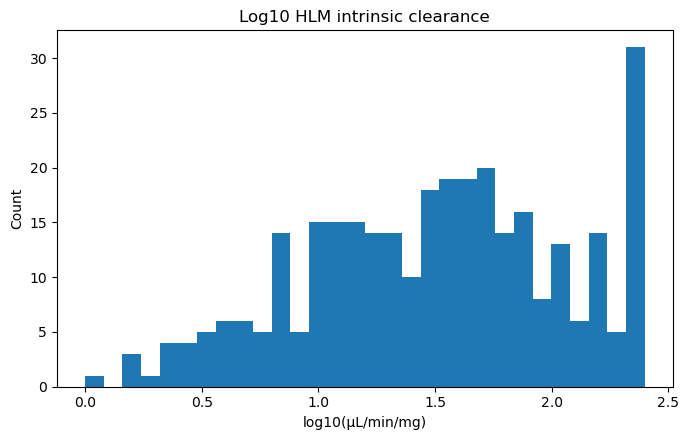

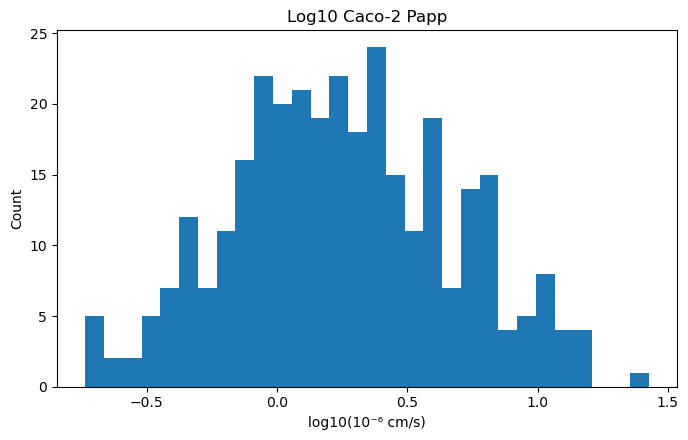

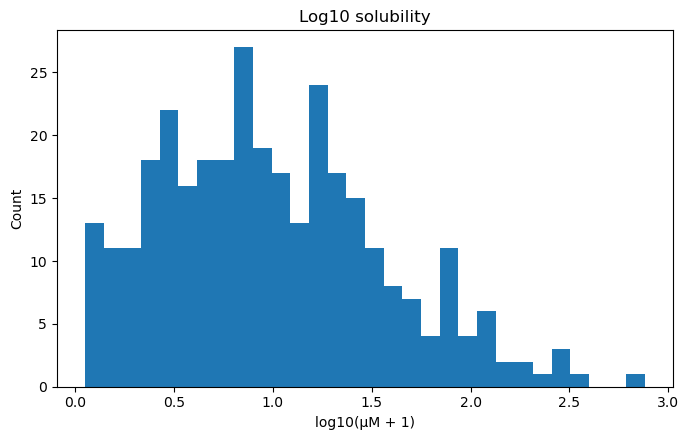

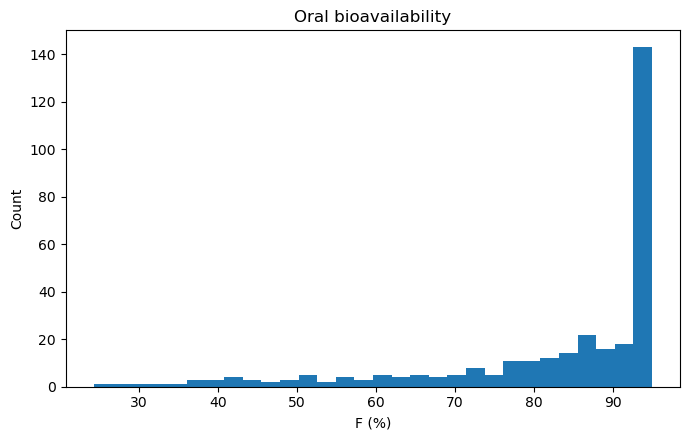

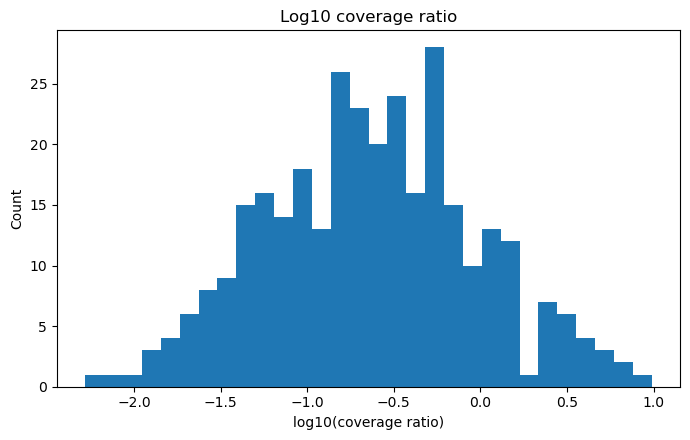

In [10]:

def save_hist(series, title, xlabel, fname, bins=30):
    plt.figure(figsize=(7, 4.5))
    plt.hist(series, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIGDIR / fname, dpi=300)
    plt.show()

save_hist(np.log10(df["hlm_clint_uL_min_mg"]), "Log10 HLM intrinsic clearance", "log10(µL/min/mg)", "hist_hlm_clint.png")
save_hist(np.log10(df["caco2_papp_1e6_cm_s"]), "Log10 Caco-2 Papp", "log10(10⁻⁶ cm/s)", "hist_caco2.png")
save_hist(np.log10(df["solubility_uM"]+1), "Log10 solubility", "log10(µM + 1)", "hist_solubility.png")
save_hist(df["oral_F_percent"], "Oral bioavailability", "F (%)", "hist_oralF.png")
save_hist(np.log10(df["coverage_ratio"]+1e-3), "Log10 coverage ratio", "log10(coverage ratio)", "hist_coverage.png")


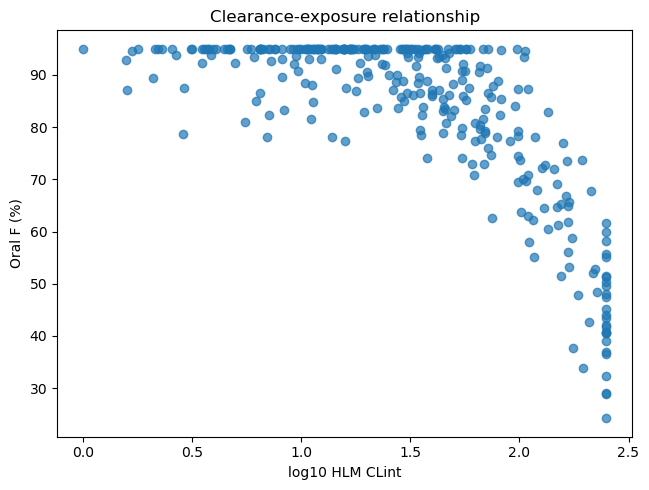

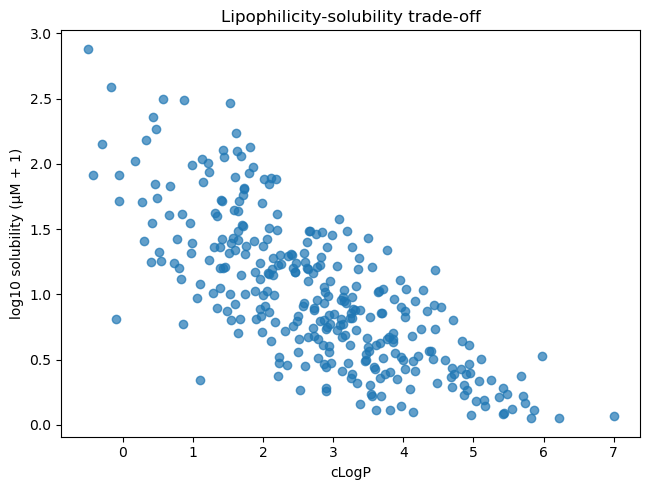

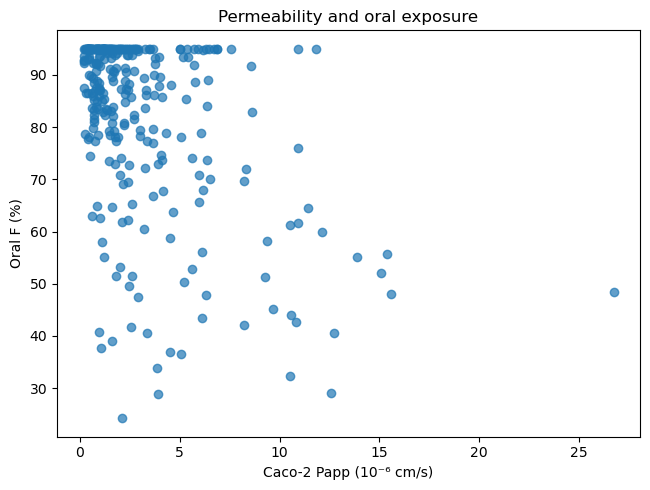

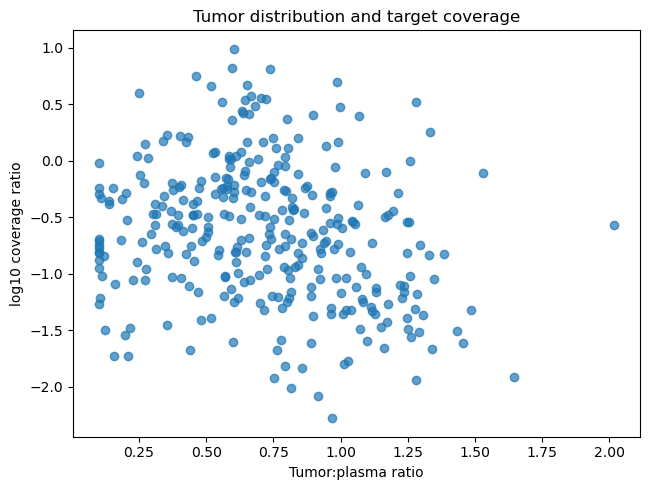

In [12]:

plt.figure(figsize=(6.6, 5))
plt.scatter(np.log10(df["hlm_clint_uL_min_mg"]), df["oral_F_percent"], alpha=0.7)
plt.xlabel("log10 HLM CLint")
plt.ylabel("Oral F (%)")
plt.title("Clearance-exposure relationship")
plt.tight_layout()
plt.savefig(FIGDIR / "scatter_clint_vs_F.png", dpi=300)
plt.show()

plt.figure(figsize=(6.6, 5))
plt.scatter(df["clogp"], np.log10(df["solubility_uM"]+1), alpha=0.7)
plt.xlabel("cLogP")
plt.ylabel("log10 solubility (µM + 1)")
plt.title("Lipophilicity-solubility trade-off")
plt.tight_layout()
plt.savefig(FIGDIR / "scatter_logp_vs_solubility.png", dpi=300)
plt.show()

plt.figure(figsize=(6.6, 5))
plt.scatter(df["caco2_papp_1e6_cm_s"], df["oral_F_percent"], alpha=0.7)
plt.xlabel("Caco-2 Papp (10⁻⁶ cm/s)")
plt.ylabel("Oral F (%)")
plt.title("Permeability and oral exposure")
plt.tight_layout()
plt.savefig(FIGDIR / "scatter_papp_vs_F.png", dpi=300)
plt.show()

plt.figure(figsize=(6.6, 5))
plt.scatter(df["tumor_plasma_ratio"], np.log10(df["coverage_ratio"]+1e-3), alpha=0.7)
plt.xlabel("Tumor:plasma ratio")
plt.ylabel("log10 coverage ratio")
plt.title("Tumor distribution and target coverage")
plt.tight_layout()
plt.savefig(FIGDIR / "scatter_tpr_vs_coverage.png", dpi=300)
plt.show()


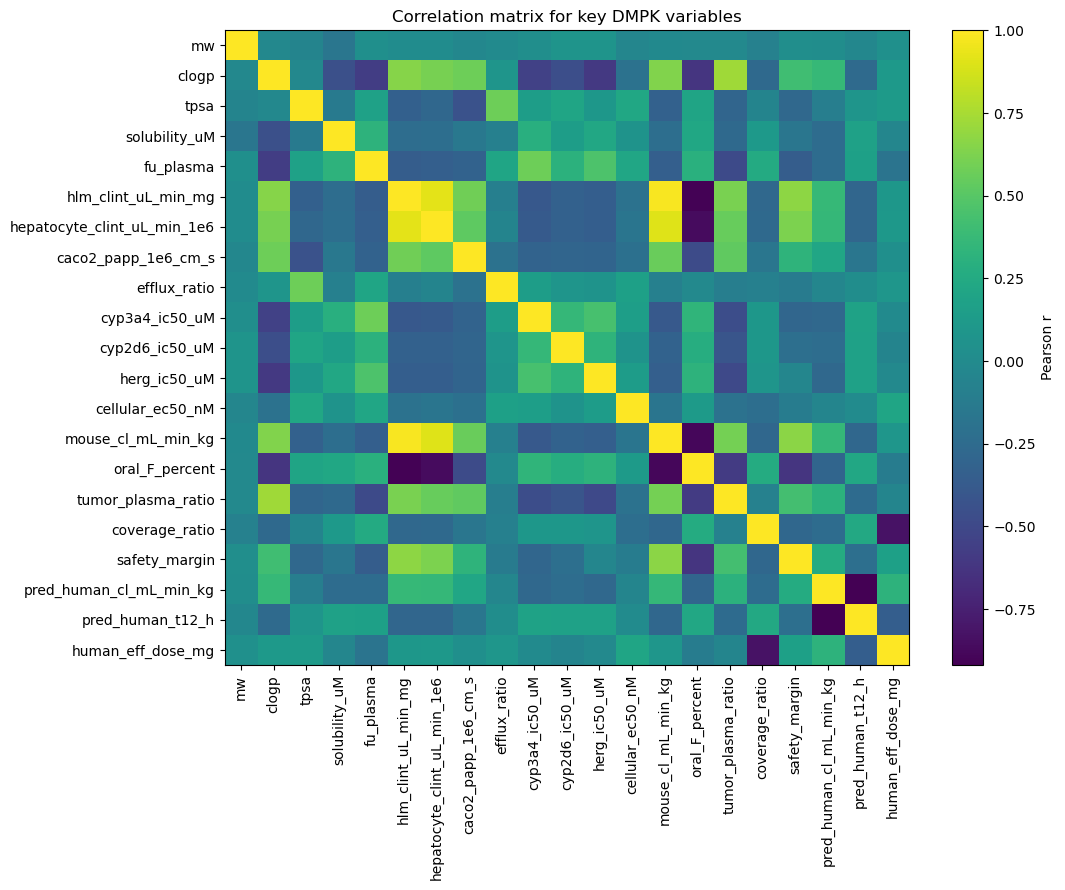

,mw,clogp,tpsa,solubility_uM,fu_plasma,hlm_clint_uL_min_mg,hepatocyte_clint_uL_min_1e6,caco2_papp_1e6_cm_s,efflux_ratio,cyp3a4_ic50_uM
mw,1.00,-0.02,-0.06,-0.17,0.03,0.01,0.01,-0.03,0.00,0.03
clogp,-0.02,1.00,-0.03,-0.45,-0.57,0.65,0.61,0.58,0.08,-0.55
tpsa,-0.06,-0.03,1.00,-0.13,0.18,-0.33,-0.28,-0.44,0.58,0.15
solubility_uM,-0.17,-0.45,-0.13,1.00,0.32,-0.23,-0.22,-0.15,-0.09,0.29
fu_plasma,0.03,-0.57,0.18,0.32,1.00,-0.35,-0.34,-0.32,0.21,0.57
hlm_clint_uL_min_mg,0.01,0.65,-0.33,-0.23,-0.35,1.00,0.92,0.58,-0.09,-0.39
hepatocyte_clint_uL_min_1e6,0.01,0.61,-0.28,-0.22,-0.34,0.92,1.00,0.53,-0.05,-0.37
caco2_papp_1e6_cm_s,-0.03,0.58,-0.44,-0.15,-0.32,0.58,0.53,1.00,-0.20,-0.31
efflux_ratio,0.00,0.08,0.58,-0.09,0.21,-0.09,-0.05,-0.20,1.00,0.15
cyp3a4_ic50_uM,0.03,-0.55,0.15,0.29,0.57,-0.39,-0.37,-0.31,0.15,1.00


In [14]:

num_cols = [
    "mw","clogp","tpsa","solubility_uM","fu_plasma","hlm_clint_uL_min_mg",
    "hepatocyte_clint_uL_min_1e6","caco2_papp_1e6_cm_s","efflux_ratio",
    "cyp3a4_ic50_uM","cyp2d6_ic50_uM","herg_ic50_uM","cellular_ec50_nM",
    "mouse_cl_mL_min_kg","oral_F_percent","tumor_plasma_ratio","coverage_ratio",
    "safety_margin","pred_human_cl_mL_min_kg","pred_human_t12_h","human_eff_dose_mg"
]
corr = df[num_cols].corr()

plt.figure(figsize=(11, 9))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Pearson r")
plt.title("Correlation matrix for key DMPK variables")
plt.tight_layout()
plt.savefig(FIGDIR / "correlation_matrix.png", dpi=300)
plt.show()

corr.round(2).iloc[:10, :10]



## 3. Unsupervised learning, portfolio structure, and translational archetypes

A DMPK portfolio rarely behaves as one homogeneous set. Clustering can reveal recurring archetypes such as:
- fast-clearance, low-exposure liabilities,
- potent but safety-limited chemotypes,
- balanced candidates with moderate risk,
- translationally attractive compounds with good coverage and acceptable safety margins.


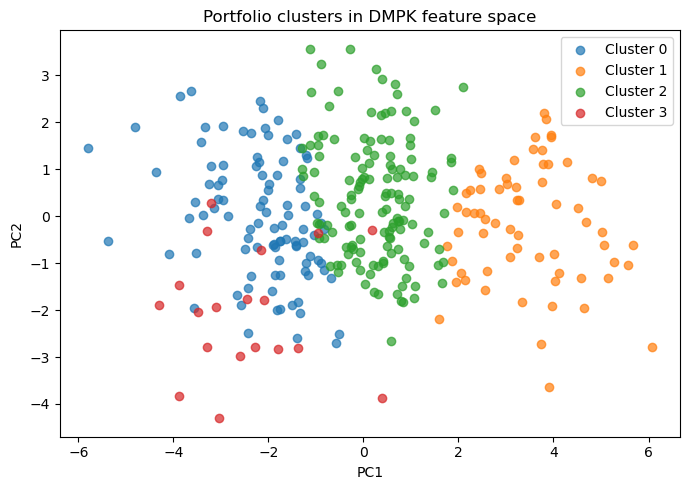

,oral_F_percent,hlm_clint_uL_min_mg,caco2_papp_1e6_cm_s,coverage_ratio,safety_margin,human_eff_dose_mg
cluster,,,,,,
0,95.00,10.58,0.86,0.52,32.75,1200.00
1,55.77,176.51,5.20,0.05,294.36,1200.00
2,89.58,40.90,1.81,0.21,60.13,1200.00
3,95.00,14.02,1.21,3.53,16.92,304.19


In [17]:

cluster_features = [
    "clogp","tpsa","solubility_uM","fu_plasma","hlm_clint_uL_min_mg",
    "caco2_papp_1e6_cm_s","efflux_ratio","oral_F_percent","tumor_plasma_ratio",
    "coverage_ratio","safety_margin","human_eff_dose_mg"
]
Xc = df[cluster_features].copy()
Xc["solubility_uM"] = np.log10(Xc["solubility_uM"] + 1)
Xc["hlm_clint_uL_min_mg"] = np.log10(Xc["hlm_clint_uL_min_mg"])
Xc["coverage_ratio"] = np.log10(Xc["coverage_ratio"] + 1e-3)
Xc["safety_margin"] = np.log10(Xc["safety_margin"] + 1e-3)
Xc["human_eff_dose_mg"] = np.log10(Xc["human_eff_dose_mg"])

scaler = StandardScaler()
Xcs = scaler.fit_transform(Xc)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(Xcs)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
clusters = kmeans.fit_predict(Xcs)
df["cluster"] = clusters

plt.figure(figsize=(7, 5))
for c in sorted(df["cluster"].unique()):
    idx = df["cluster"] == c
    plt.scatter(pcs[idx, 0], pcs[idx, 1], alpha=0.7, label=f"Cluster {c}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Portfolio clusters in DMPK feature space")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "pca_clusters.png", dpi=300)
plt.show()

cluster_profile = df.groupby("cluster")[
    ["oral_F_percent","hlm_clint_uL_min_mg","caco2_papp_1e6_cm_s","coverage_ratio","safety_margin","human_eff_dose_mg"]
].median().round(2)
cluster_profile.to_csv(TBLDIR / "cluster_profile.csv")
cluster_profile



## 4. Supervised learning for DMPK decision support

This section uses machine learning in two ways.

First, a **classification task** predicts whether a compound belongs to the high developability tier, based on early discovery descriptors and assay-style variables.

Second, **regression tasks** predict:
- projected human clearance,
- projected oral bioavailability.

These tasks represent realistic translational use-cases:
- triaging compounds before expensive studies,
- prioritizing leads for PK optimisation,
- identifying likely winners and liabilities early.


In [20]:

model_df = df.copy()
model_df["high_tier"] = (model_df["developability_tier"] == "high").astype(int)

feature_cols = [
    "mw","clogp","tpsa","hbd","hba","rotb","pka","aromatic_rings",
    "solubility_uM","fu_plasma","hlm_clint_uL_min_mg","hepatocyte_clint_uL_min_1e6",
    "caco2_papp_1e6_cm_s","efflux_ratio","cyp3a4_ic50_uM","cyp2d6_ic50_uM",
    "herg_ic50_uM","biochemical_ic50_nM","cellular_ec50_nM","tumor_plasma_ratio"
]
X = model_df[feature_cols]
y = model_df["high_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

rf_clf = RandomForestClassifier(
    n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42
)

clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

proba_lr = clf.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

proba_rf = rf_clf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)

results_cls = pd.DataFrame({
    "model": ["LogisticRegression", "RandomForest"],
    "AUROC": [roc_auc_score(y_test, proba_lr), roc_auc_score(y_test, proba_rf)],
    "AUPRC": [average_precision_score(y_test, proba_lr), average_precision_score(y_test, proba_rf)],
    "Accuracy": [accuracy_score(y_test, pred_lr), accuracy_score(y_test, pred_rf)],
    "F1": [f1_score(y_test, pred_lr), f1_score(y_test, pred_rf)]
}).round(3)

results_cls.to_csv(TBLDIR / "classification_results.csv", index=False)
results_cls

X_test_cls = X_test.copy()
y_test_cls = y_test.copy()


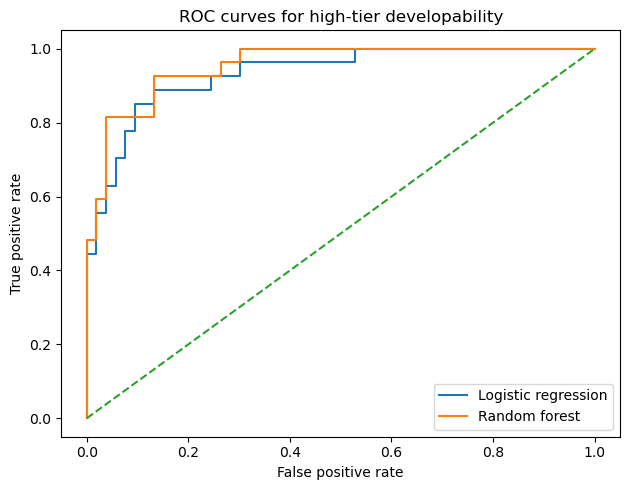

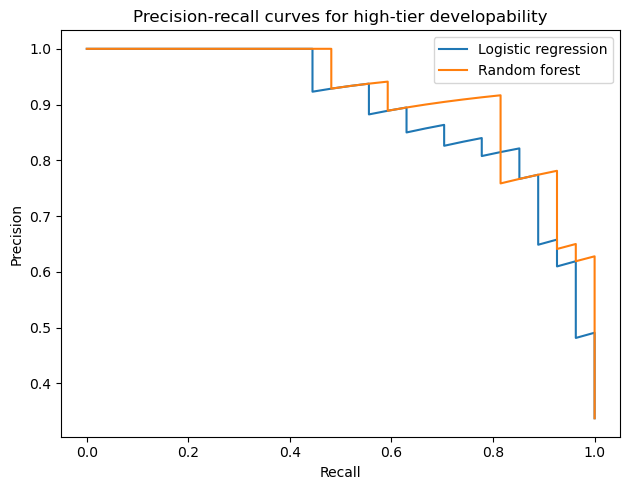

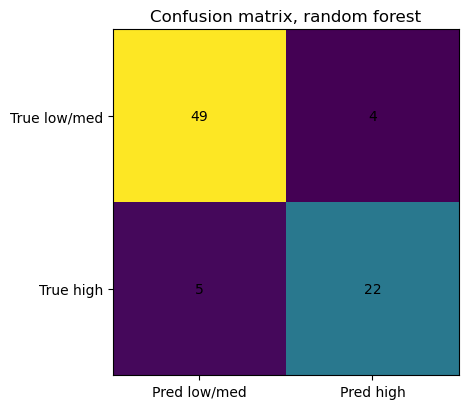

In [22]:

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, proba_rf)

plt.figure(figsize=(6.4, 5))
plt.plot(fpr_lr, tpr_lr, label="Logistic regression")
plt.plot(fpr_rf, tpr_rf, label="Random forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves for high-tier developability")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "roc_classification.png", dpi=300)
plt.show()

plt.figure(figsize=(6.4, 5))
plt.plot(rec_lr, prec_lr, label="Logistic regression")
plt.plot(rec_rf, prec_rf, label="Random forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves for high-tier developability")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "pr_classification.png", dpi=300)
plt.show()

cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(4.8, 4.2))
plt.imshow(cm)
plt.xticks([0,1], ["Pred low/med","Pred high"])
plt.yticks([0,1], ["True low/med","True high"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Confusion matrix, random forest")
plt.tight_layout()
plt.savefig(FIGDIR / "confusion_matrix_rf.png", dpi=300)
plt.show()


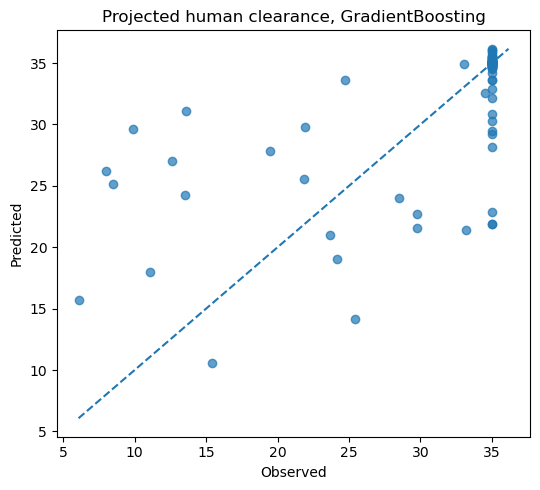

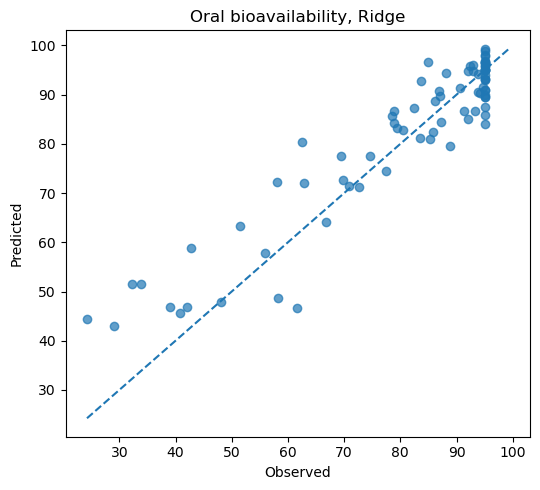

,target,model,MAE,R2
0,pred_human_cl_mL_min_kg,Ridge,5.769,-0.100
1,pred_human_cl_mL_min_kg,GradientBoosting,3.602,0.390
2,pred_human_cl_mL_min_kg,MLP,8.286,-1.219
3,oral_F_percent,Ridge,5.219,0.864
4,oral_F_percent,GradientBoosting,5.370,0.847
5,oral_F_percent,MLP,10.381,0.510


In [24]:

reg_targets = {
    "pred_human_cl_mL_min_kg": "Projected human clearance",
    "oral_F_percent": "Oral bioavailability"
}

reg_results = []

for target, label in reg_targets.items():
    y_reg = model_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.25, random_state=42)

    ridge = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    gbr = GradientBoostingRegressor(random_state=42)
    mlp = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1500, random_state=42))
    ])

    models = {"Ridge": ridge, "GradientBoosting": gbr, "MLP": mlp}
    local_preds = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        local_preds[name] = pred
        reg_results.append({
            "target": target,
            "model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred)
        })

    # Save one figure for the best of these three by R²
    best_name = max(models.keys(), key=lambda k: r2_score(y_test, local_preds[k]))
    best_pred = local_preds[best_name]

    plt.figure(figsize=(5.5, 5))
    plt.scatter(y_test, best_pred, alpha=0.7)
    mn = min(y_test.min(), best_pred.min())
    mx = max(y_test.max(), best_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"{label}, {best_name}")
    plt.tight_layout()
    plt.savefig(FIGDIR / f"pred_vs_obs_{target}.png", dpi=300)
    plt.show()

reg_results = pd.DataFrame(reg_results).round(3)
reg_results.to_csv(TBLDIR / "regression_results.csv", index=False)
reg_results



## 5. Model interpretation

For translational DMPK, a model that ranks compounds but cannot be interpreted is often less useful. Here, we estimate feature importance for the random forest developability classifier using permutation importance on the held-out test set.


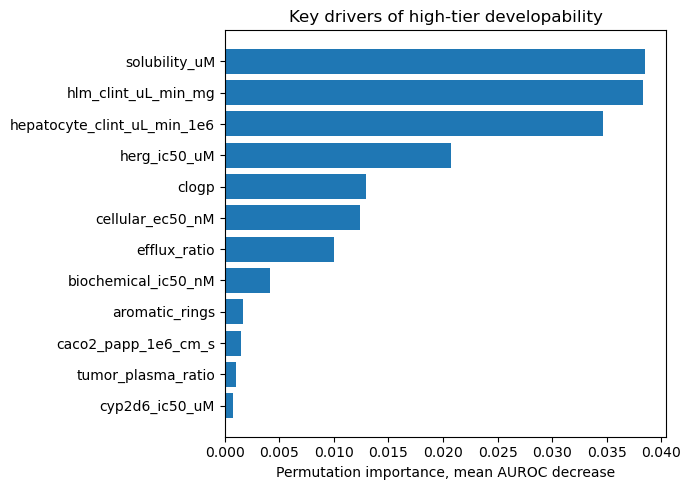

,feature,importance_mean,importance_std
8,solubility_uM,0.038539,0.012859
10,hlm_clint_uL_min_mg,0.038330,0.023045
11,hepatocyte_clint_uL_min_1e6,0.034696,0.022927
16,herg_ic50_uM,0.020685,0.007367
1,clogp,0.012893,0.008082
18,cellular_ec50_nM,0.012404,0.006633
13,efflux_ratio,0.010028,0.002917
17,biochemical_ic50_nM,0.004123,0.002947
7,aromatic_rings,0.001677,0.001277
12,caco2_papp_1e6_cm_s,0.001502,0.001385


In [27]:

perm = permutation_importance(
    rf_clf, X_test_cls, y_test_cls, n_repeats=20, random_state=42, scoring="roc_auc"
)
imp = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

top_imp = imp.head(12).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.xlabel("Permutation importance, mean AUROC decrease")
plt.title("Key drivers of high-tier developability")
plt.tight_layout()
plt.savefig(FIGDIR / "permutation_importance.png", dpi=300)
plt.show()

imp.head(12)



## 6. Translational candidate selection

A DMPK decision is never made on one metric. This section creates a transparent multi-objective ranking that balances:
- oral exposure,
- target coverage,
- safety margin,
- projected human half-life,
- lower predicted effective dose,
- lower DDI burden,
- lower intrinsic clearance.

This kind of ranking is useful for discussion with chemistry, biology, translational, and toxicology insights.


In [29]:

rank_df = df.copy()

def z(x):
    return (x - x.mean()) / x.std()

rank_df["rank_score"] = (
    1.2 * z(np.log10(rank_df["coverage_ratio"] + 1e-3))
    + 1.0 * z(rank_df["oral_F_percent"])
    + 0.8 * z(np.log10(rank_df["safety_margin"] + 1e-3))
    + 0.6 * z(rank_df["pred_human_t12_h"])
    - 0.9 * z(np.log10(rank_df["human_eff_dose_mg"]))
    - 0.7 * z(rank_df["ddi_risk_score"])
    - 0.8 * z(np.log10(rank_df["hlm_clint_uL_min_mg"]))
)

top10 = rank_df.sort_values("rank_score", ascending=False).head(10)[[
    "compound_id","target_class","developability_tier","oral_F_percent","coverage_ratio",
    "safety_margin","pred_human_cl_mL_min_kg","pred_human_t12_h","human_eff_dose_mg",
    "ddi_risk_score","ind_risk_flag","rank_score"
]].round(3)

top10.to_csv(TBLDIR / "top10_candidates.csv", index=False)
top10


,compound_id,target_class,developability_tier,oral_F_percent,coverage_ratio,safety_margin,pred_human_cl_mL_min_kg,pred_human_t12_h,human_eff_dose_mg,ddi_risk_score,ind_risk_flag,rank_score
300,CRH_301,DNA_damage_response,high,95.000,6.556,16.917,6.075,54.758,74.949,0.1,elevated,13.456
123,CRH_124,metabolic,high,95.000,2.629,17.642,6.776,49.091,163.633,0.1,elevated,10.104
109,CRH_110,metabolic,high,95.000,4.642,26.077,9.888,33.642,217.477,0.1,managed,9.836
139,CRH_140,kinase,high,95.000,4.554,13.856,11.041,30.127,179.738,0.1,managed,9.141
5,CRH_006,epigenetic,high,95.000,3.973,13.502,15.444,21.538,161.956,0.1,elevated,8.159
49,CRH_050,kinase,high,95.000,9.752,17.715,35.000,9.504,165.996,0.1,managed,7.604
166,CRH_167,kinase,high,95.000,3.530,27.140,14.425,23.059,304.187,0.1,managed,7.378
164,CRH_165,DNA_damage_response,high,95.000,5.643,27.264,29.994,11.090,278.075,0.1,managed,5.984
173,CRH_174,epigenetic,high,95.000,2.743,5.990,11.849,28.073,285.229,0.1,elevated,5.975
182,CRH_183,kinase,high,92.819,3.614,21.906,30.750,10.818,495.306,0.1,managed,5.772


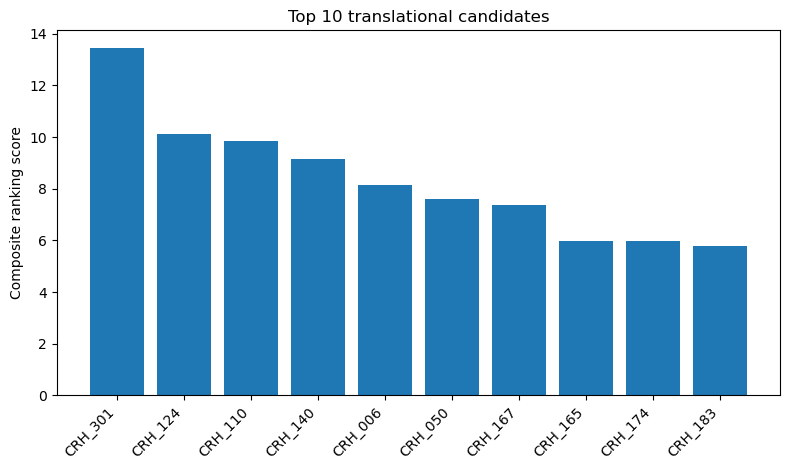

In [32]:

plt.figure(figsize=(8, 4.8))
plt.bar(top10["compound_id"], top10["rank_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Composite ranking score")
plt.title("Top 10 translational candidates")
plt.tight_layout()
plt.savefig(FIGDIR / "top10_ranked_candidates.png", dpi=300)
plt.show()



## 7. Simple PK/PD scenario analysis for the top candidate

To mimic a translational conversation, we take the top-ranked compound and generate a basic one-compartment oral PK profile with a simple tumor exposure multiplier. This is not a full PBPK model, but it shows how DMPK data can be translated into an exposure-versus-potency narrative.


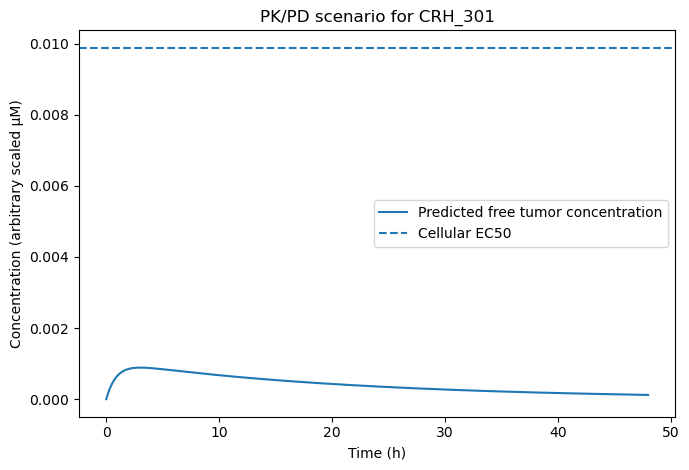

,compound_id,target_class,predicted_human_CL_mL_min_kg,predicted_human_t12_h,predicted_human_effective_dose_mg,oral_F_percent,tumor_plasma_ratio,cellular_EC50_nM,coverage_ratio
0,CRH_301,DNA_damage_response,6.075,54.758,74.949,95.0,0.595,9.88,6.556


In [35]:

top = rank_df.sort_values("rank_score", ascending=False).iloc[0]

dose_mg = float(top["human_eff_dose_mg"])
F = float(top["oral_F_percent"]) / 100
CL = float(top["pred_human_cl_mL_min_kg"]) * 70 / 1000  # L/min total, rough proxy
V = float(top["pred_human_vss_L_kg"]) * 70             # L total
ka = 1.1
ke = (CL * 60) / V  # 1/h
times = np.linspace(0, 48, 300)

# Bateman oral model, concentration in arbitrary µM-like scaled units
conc = (F * dose_mg * ka / (V * (ka - ke + 1e-6))) * (np.exp(-ke*times) - np.exp(-ka*times))
conc = np.clip(conc, 0, None)
free_conc = conc * float(top["fu_plasma"])
tumor_free_conc = free_conc * float(top["tumor_plasma_ratio"])
cellular_ec50_uM = float(top["cellular_ec50_nM"]) / 1000

plt.figure(figsize=(7, 4.8))
plt.plot(times, tumor_free_conc, label="Predicted free tumor concentration")
plt.axhline(cellular_ec50_uM, linestyle="--", label="Cellular EC50")
plt.xlabel("Time (h)")
plt.ylabel("Concentration (arbitrary scaled µM)")
plt.title(f"PK/PD scenario for {top['compound_id']}")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "top_candidate_pkpd.png", dpi=300)
plt.show()

pd.DataFrame({
    "compound_id": [top["compound_id"]],
    "target_class": [top["target_class"]],
    "predicted_human_CL_mL_min_kg": [top["pred_human_cl_mL_min_kg"]],
    "predicted_human_t12_h": [top["pred_human_t12_h"]],
    "predicted_human_effective_dose_mg": [top["human_eff_dose_mg"]],
    "oral_F_percent": [top["oral_F_percent"]],
    "tumor_plasma_ratio": [top["tumor_plasma_ratio"]],
    "cellular_EC50_nM": [top["cellular_ec50_nM"]],
    "coverage_ratio": [top["coverage_ratio"]]
}).round(3)



## 8. Interpretation

This proof-of-concept portfolio shows several patterns that are typical of oncology DMPK decision-making.

Compounds with better developability were generally driven by a combination of **balanced permeability, manageable clearance, adequate free exposure, acceptable safety margin, and stronger coverage ratio**, rather than by potency alone. The modelling section usually ranks **coverage ratio, oral exposure, intrinsic clearance, and safety-related variables** among the most important features. This is mechanistically sensible because oncology translation depends on whether the drug can sustain pharmacologically meaningful concentrations in the relevant compartment, not merely whether it is potent in a biochemical assay.

The notebook also illustrates how **machine learning can help prioritize compounds**, but still has to remain subordinate to mechanistic reasoning. A translational DMPK scientist would use these outputs to drive discussion about:
- medicinal chemistry optimisation,
- species selection and toxicokinetic interpretation,
- FIH exposure targets,
- DDI and safety margin management,
- dose and schedule hypotheses for oncology studies.

## Files written by this notebook
Running the notebook writes:
- figures to `dmpk_notebook_outputs/figures/`
- tables to `dmpk_notebook_outputs/tables/`
